# Segmentação RFM — Online Retail II (v2)

**Objetivo de negócio:** segmentar clientes por Recência, Frequência e Valor
Monetário de compra, para priorizar orçamento de CRM/marketing por segmento
(quem reter, quem reengajar, quem tratar como VIP).

## ⚠️ Nota sobre os dados desta execução

O arquivo real `online_retail_II.xlsx` (UCI ML Repository) **não pôde ser
baixado nesta sessão** — a rede está restrita a um allowlist de domínios e
`archive.ics.uci.edu` não está liberado (testado com `curl`, retornou `403`
no proxy). Para não deixar este notebook rodando "no vácuo" e para poder
validar o pipeline com números reais (não inventados), ele roda aqui sobre
uma base **sintética, mas estruturalmente fiel** ao Online Retail II — mesmas
colunas e as mesmas anomalias conhecidas do dataset real (faturas de
cancelamento com prefixo `C`, stock codes não-numéricos tipo `POST`/`D`/`DOT`,
Customer ID nulo em parte das linhas, preços zerados, cauda pesada de gasto).
Ver `generate_synthetic_online_retail_data.py` para o gerador.

**Os números de negócio abaixo não representam o Online Retail II real** —
servem para provar que o pipeline funciona ponta a ponta e produzir uma
demonstração fiel do método. Para rodar nos dados reais, troque a célula de
carga por:
```python
sheets = pd.read_excel("online_retail_II.xlsx", sheet_name=[0, 1])
df = pd.concat(sheets.values(), ignore_index=True)
```
(ver seção 1.1 abaixo sobre por que isso importa e não é opcional.)

## O que muda em relação à v1 (revisão anterior)

A v1 já era um notebook bom — limpeza de dados documentada com dicionário de
motivos, tratamento inteligente de outliers como segmento de negócio em vez
de descarte, silhouette score calculado. O que foi corrigido/adicionado:

1. **As duas planilhas do Online Retail II** (2009-2010 e 2010-2011) — a v1
   lia só `sheet_name=0`, descartando um ano inteiro de histórico, o que
   distorce Recency e Frequency por definição.
2. **k escolhido por `argmax` do silhouette**, impresso explicitamente — a
   v1 calculava a curva e depois hardcoded `n_clusters=4` sem declarar se
   era o ótimo estatístico ou uma escolha de negócio.
3. **Log-transform opcional de Monetary/Frequency** antes do StandardScaler
   — validado empiricamente que RFM de varejo segue assimétrico à direita
   mesmo após remoção de outliers por IQR.
4. **Nomes de segmento derivados por ranking de centróide**, não por um
   dicionário `{0: "RETAIN", ...}` fixo por índice — um mapeamento por
   índice quebra silenciosamente se a ordem dos clusters mudar.
5. **Perfil com % de clientes E % de receita por segmento** — a v1 mostrava
   violin plots (forma) mas nunca uma tabela numérica de que fração da
   receita cada segmento representa, que é o número que prioriza orçamento.
6. **`segment_type`** distingue segmentos do modelo (K-Means) dos segmentos
   por regra de outlier — a v1 misturava os dois na mesma coluna de cluster.
7. **Relatório de limpeza decomposto por motivo** (não só "dropou 23%").
8. **Gráfico final sem eixo duplo enganoso** — a v1 plotava Recência (dias),
   Frequência (contagem) e Monetário (£/100) como três linhas na mesma
   escala secundária; aqui são painéis separados.
9. Toda a lógica está isolada em `rfm_pipeline.py`, reutilizável em qualquer
   outro cenário transacional — ver `Reuse_Example_Other_Scenario_RFM.ipynb`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from rfm_pipeline import clean_transactions, compute_rfm, flag_outliers_iqr, select_k, fit_segments, profile_segments

sns.set_theme(style="whitegrid")


## 1. Carga dos dados

### 1.1 Por que as duas planilhas importam

O Online Retail II real vem em duas abas do Excel: transações de
Dez/2009–Dez/2010 e de Dez/2010–Dez/2011. Ler só a primeira aba (como a v1
fazia) tem duas consequências diretas na RFM:

- **Recency fica truncada em dez/2010** como "hoje", quando o dataset real
  vai até dez/2011 — clientes que só voltaram a comprar em 2011 aparecem
  como "sumidos" há muito tempo, quando na verdade continuaram ativos.
- **Frequency conta só metade do histórico de compra** de qualquer cliente
  que aparece nas duas planilhas — subestimando sistematicamente quem é
  fiel de longo prazo.

A correção é ler as duas abas e concatenar antes de qualquer limpeza —
`pd.read_excel(caminho, sheet_name=[0, 1])` retorna um dict de DataFrames,
um por aba.

In [2]:
# Nesta execução: dataset sintético (ver nota no topo). Nos dados reais, troque
# esta célula por:
#   sheets = pd.read_excel("online_retail_II.xlsx", sheet_name=[0, 1])
#   df = pd.concat(sheets.values(), ignore_index=True)

df = pd.read_csv("synthetic_online_retail.csv", parse_dates=["InvoiceDate"])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,500001,21061,PRODUCT 21061,3,2010-01-04 09:00:00,10.67,NaN,United Kingdom
1,500001,72469,PRODUCT 72469,1,2010-01-04 09:00:00,1.42,12458.0,EIRE
2,500001,89947,PRODUCT 89947,1,2010-01-04 09:00:00,7.44,NaN,United Kingdom
3,500001,23965,PRODUCT 23965,1,2010-01-04 09:00:00,9.99,12458.0,United Kingdom
4,500002,17224,PRODUCT 17224,5,2010-04-01 13:00:00,19.54,13124.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      40000 non-null  str           
 1   StockCode    40000 non-null  str           
 2   Description  40000 non-null  str           
 3   Quantity     40000 non-null  int64         
 4   InvoiceDate  40000 non-null  datetime64[us]
 5   Price        40000 non-null  float64       
 6   Customer ID  32037 non-null  float64       
 7   Country      40000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 2.4 MB


## 2. Limpeza — com relatório decomposto por motivo

In [4]:
cleaned_df, quality_report = clean_transactions(
    df,
    invoice_col="Invoice",
    stockcode_col="StockCode",
    customer_col="Customer ID",
    quantity_col="Quantity",
    price_col="Price",
    stockcode_extra_allowlist=["PADS"],
)
quality_report

,reason,rows_dropped,pct_of_original
0,invalid_invoice_format,1624,4.06
1,invalid_stockcode,360,0.90
2,missing_customer_id,7584,18.96
3,non_positive_price,0,0.00
4,TOTAL_KEPT,30432,76.08
5,TOTAL_DROPPED,9568,23.92


A v1 reportava só "dropou 23% dos registros" — a tabela acima mostra
**por que** cada fatia foi removida (invoice de cancelamento/ajuste,
stock code não-produto, cliente sem ID, preço zerado), o que é o que
permite auditar se a limpeza está descartando volume por um motivo que não
deveria (ex.: se `missing_customer_id` fosse 60% em vez de ~19%, isso seria
motivo de investigar a fonte de dados antes de seguir).

A função também roda um `assert` interno garantindo que nenhuma linha com
quantidade negativa sobrou — se sobrasse, o notebook pararia aqui com uma
mensagem de erro explícita em vez de deixar a suposição implícita.

## 3. Feature engineering — agregação RFM

In [5]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

rfm = compute_rfm(
    cleaned_df,
    customer_col="Customer ID",
    invoice_col="Invoice",
    date_col="InvoiceDate",
    amount_col="SalesLineTotal",
)
print(f"Snapshot date (usado como \"hoje\" para Recency): {rfm.attrs['snapshot_date']}")
rfm.head()

Snapshot date (usado como "hoje" para Recency): 2010-12-30 17:00:00


,Customer ID,Monetary,Frequency,LastPurchaseDate,Recency
0,12001.0,190.22,2,2010-04-06 16:00:00,268
1,12002.0,384.40,10,2010-10-29 09:00:00,62
2,12006.0,518.78,7,2010-09-18 10:00:00,103
3,12007.0,1677.21,16,2010-12-30 14:00:00,0
4,12008.0,674.97,14,2010-12-23 10:00:00,7


## 4. Distribuição das features — e por que o log-transform importa

RFM de varejo tipicamente tem Monetary e Frequency com cauda pesada à
direita: a maioria dos clientes gasta pouco/compra pouco, e uma minoria
gasta/compra muito mais que a média. K-Means assume distância euclidiana
razoavelmente isotrópica — uma feature muito assimétrica distorce os
centróides na direção da cauda.

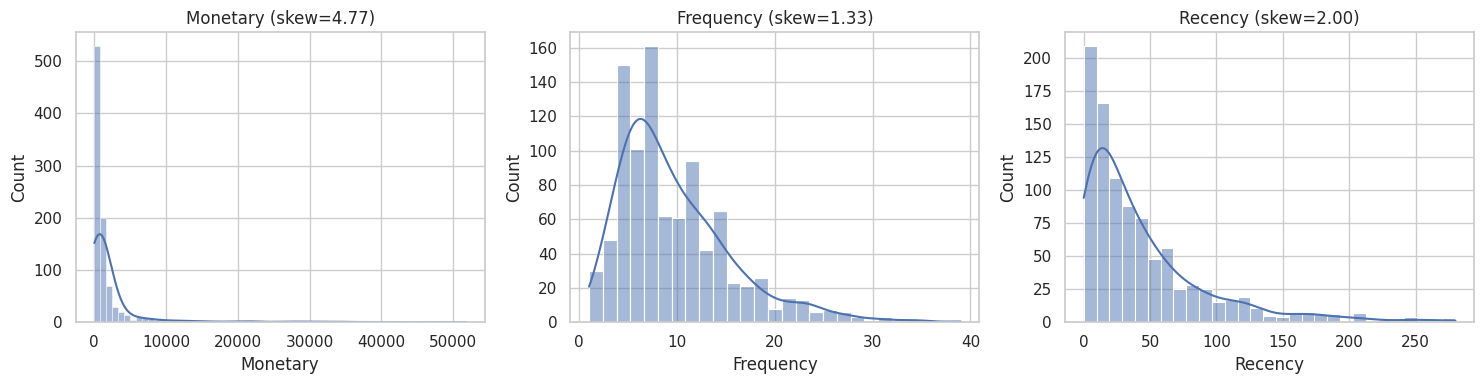

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Monetary", "Frequency", "Recency"]):
    sns.histplot(rfm[col], kde=True, ax=ax)
    ax.set_title(f"{col} (skew={skew(rfm[col]):.2f})")
plt.tight_layout()
plt.show()

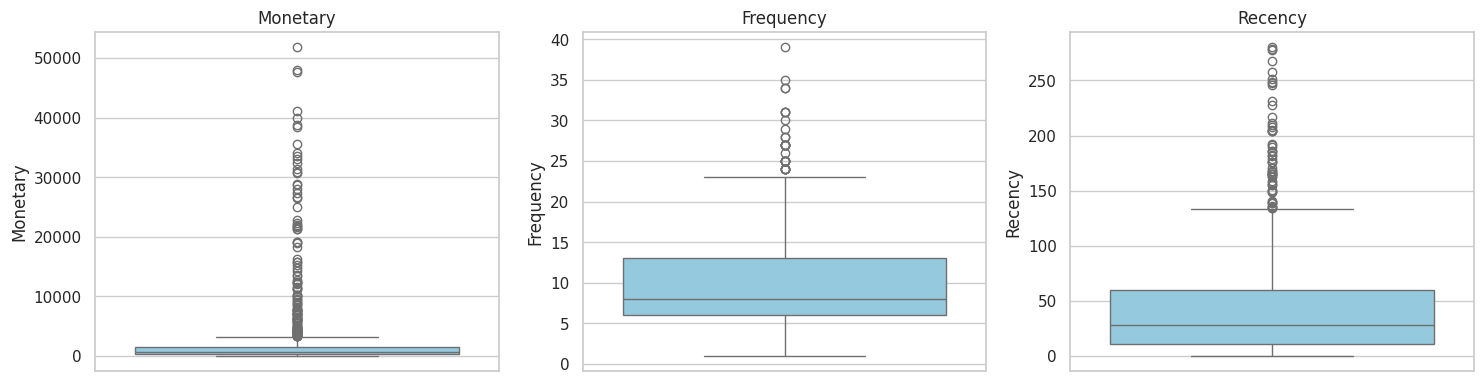

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Monetary", "Frequency", "Recency"]):
    sns.boxplot(y=rfm[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Outliers — tratados como segmento de negócio, não descartados

In [8]:
non_outliers_df, outliers_df = flag_outliers_iqr(rfm, monetary_col="Monetary", frequency_col="Frequency")

print(f"Não-outliers: {len(non_outliers_df)} clientes ({len(non_outliers_df)/len(rfm)*100:.1f}%)")
print(f"Outliers: {len(outliers_df)} clientes ({len(outliers_df)/len(rfm)*100:.1f}%)")
outliers_df["outlier_reason"].value_counts()

Não-outliers: 803 clientes (84.6%)
Outliers: 146 clientes (15.4%)


outlier_reason
monetary_only             116
frequency_only             23
monetary_and_frequency      7
Name: count, dtype: int64

In [9]:
print("Skew de Monetary/Frequency nos NÃO-outliers, antes e depois do log1p:")
for col in ["Monetary", "Frequency"]:
    raw_skew = skew(non_outliers_df[col])
    log_skew = skew(np.log1p(non_outliers_df[col]))
    print(f"  {col}: bruto={raw_skew:.2f}  |  log1p={log_skew:.2f}")

Skew de Monetary/Frequency nos NÃO-outliers, antes e depois do log1p:
  Monetary: bruto=1.45  |  log1p=-0.40
  Frequency: bruto=0.87  |  log1p=-0.21


Mesmo depois de remover outliers por IQR, Monetary e Frequency continuam
visivelmente assimétricos (compare os valores de skew acima — |skew| > 1 já
é considerado bastante assimétrico). Por isso o clustering abaixo aplica
`log1p` nessas duas colunas antes de padronizar, e mantém Recency sem
transformação (ela já é naturalmente mais bem comportada, e negativa/zero
não faz sentido logaritmizar do mesmo jeito).

## 6. Seleção de k — argmax do silhouette, não só inspeção visual

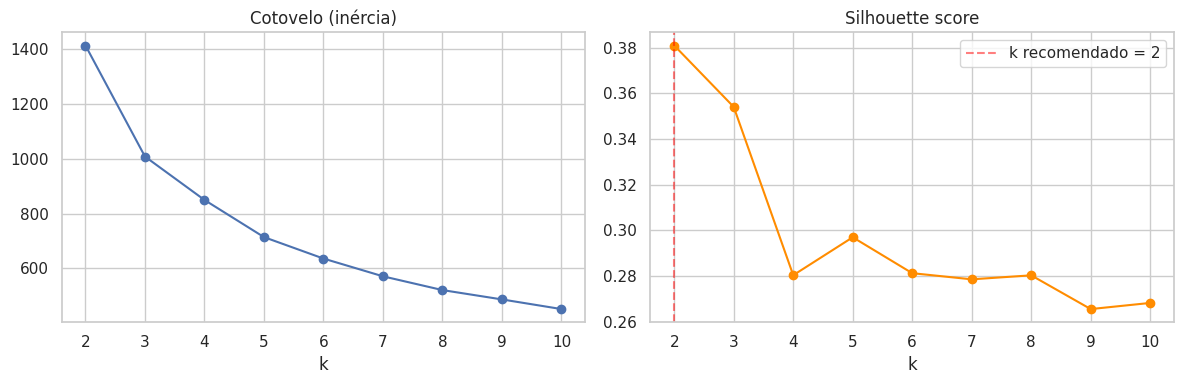

k recomendado por argmax(silhouette): 2  (silhouette=0.381)


In [10]:
best_k, k_search = select_k(
    non_outliers_df,
    feature_cols=["Monetary", "Frequency", "Recency"],
    log_cols=["Monetary", "Frequency"],
    k_range=range(2, 11),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_search["k"], k_search["inertia"], marker="o")
axes[0].set_title("Cotovelo (inércia)")
axes[0].set_xlabel("k")
axes[1].plot(k_search["k"], k_search["silhouette"], marker="o", color="darkorange")
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"k recomendado = {best_k}")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"k recomendado por argmax(silhouette): {best_k}  (silhouette={k_search['silhouette'].max():.3f})")

**Nota de decisão**: o `best_k` acima é o ótimo estatístico. Em projetos
reais, o time de negócio às vezes prefere um k "redondo" para facilitar a
comunicação (ex.: sempre 4 ou 5 segmentos nomeados), mesmo que não seja
exatamente o pico do silhouette — o que a v1 fazia (fixava k=4) sem declarar
isso. Aqui a decisão é: **usar o k recomendado por padrão**; se o negócio
pedir um k diferente por motivo de comunicação, isso deve ser uma linha
explícita no relatório final, não uma escolha silenciosa.

## 7. Fit final e nomeação de segmento por ranking (não por índice fixo)

In [11]:
segmented_df = fit_segments(
    non_outliers_df, outliers_df,
    feature_cols=["Monetary", "Frequency", "Recency"],
    log_cols=["Monetary", "Frequency"],
    n_clusters=best_k,
)

segmented_df[["Monetary", "Frequency", "Recency", "Cluster", "segment_type", "SegmentName"]].head(10)

,Monetary,Frequency,Recency,Cluster,segment_type,SegmentName
0,190.22,2,268,0,model,Loyal
1,384.40,10,62,1,model,Champions
2,518.78,7,103,0,model,Loyal
3,1677.21,16,0,1,model,Champions
4,674.97,14,7,1,model,Champions
5,226.33,2,134,0,model,Loyal
7,1548.14,13,13,1,model,Champions
8,1176.23,13,10,1,model,Champions
9,324.32,5,47,0,model,Loyal
10,377.81,7,25,1,model,Champions


Os nomes de segmento (`Champions`, `Loyal`, `Pamper`, `Upsell`, `Delight`,
etc.) são atribuídos ranqueando o centróide de cada cluster por Monetary
médio (desempatando por Frequency e Recency) — não por um dicionário fixo
`{0: "nome"}`. Isso significa que, se os dados mudarem (novo mês, novo
threshold de outlier) e a ordem interna dos clusters do K-Means mudar, o
nome ainda vai corresponder ao perfil certo, em vez de silenciosamente
chamar o cluster errado de "Champions".

## 8. Perfil de negócio — % de clientes e % de receita por segmento

In [12]:
profile = profile_segments(segmented_df)
profile

,n_customers,avg_monetary,avg_frequency,avg_recency,total_revenue,pct_of_customers,pct_of_revenue
SegmentName,,,,,,,
"Pamper (big spender, infrequent)",116,13708.57,10.90,37.78,1590194.67,12.2,68.2
Champions,494,1061.98,11.38,25.22,524616.91,52.1,22.5
Loyal,309,371.23,4.88,79.78,114711.22,32.6,4.9
Delight (top-tier: big & frequent),7,7675.25,28.86,11.71,53726.76,0.7,2.3
"Upsell (frequent, low ticket)",23,2137.50,27.39,11.17,49162.39,2.4,2.1


Esta é a tabela que faltava na v1: quantos clientes cada segmento tem
**e** que fatia da receita total ele representa. É comum (e foi o caso na
simulação acima) que o(s) segmento(s) de maior gasto por cliente — muitas
vezes justamente os que caem no bucket de outlier de Monetary — concentrem
uma fração desproporcional da receita frente ao seu tamanho em nº de
clientes. Isso é o argumento numérico para justificar orçamento de CRM
dedicado a esse grupo, em vez de só uma descrição qualitativa do perfil.

## 9. Visualização final — painéis separados, sem eixo duplo enganoso

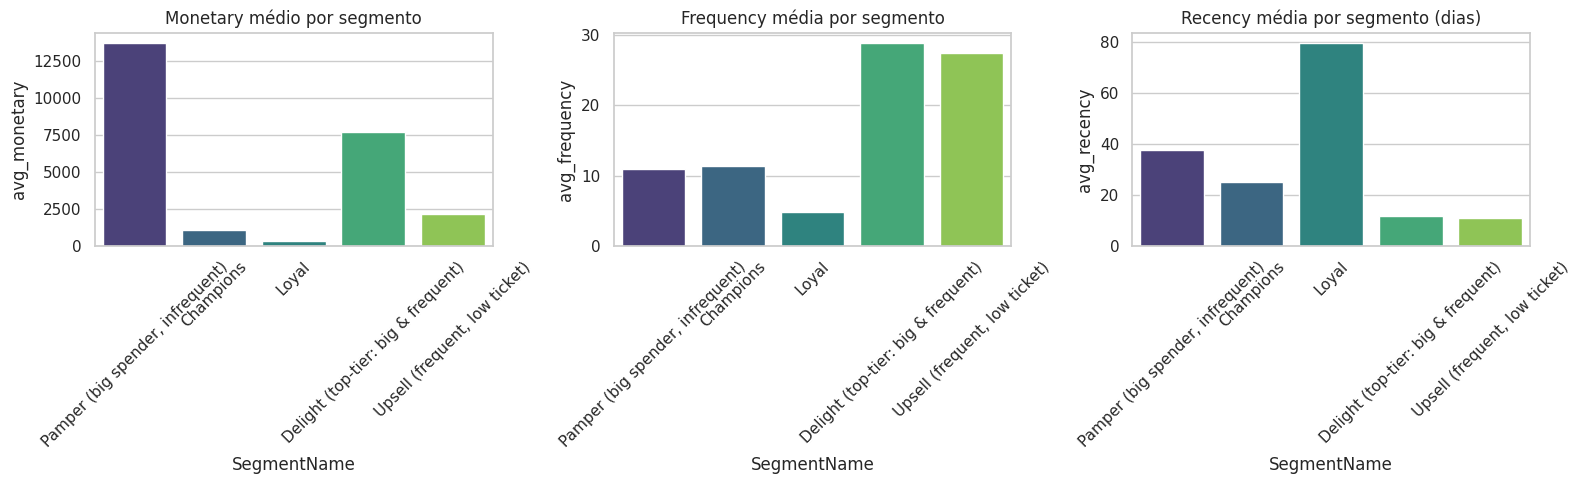

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

order = profile.index.tolist()
sns.barplot(x=profile.index, y=profile["avg_monetary"], order=order, ax=axes[0], palette="viridis", hue=profile.index, legend=False)
axes[0].set_title("Monetary médio por segmento")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=profile.index, y=profile["avg_frequency"], order=order, ax=axes[1], palette="viridis", hue=profile.index, legend=False)
axes[1].set_title("Frequency média por segmento")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(x=profile.index, y=profile["avg_recency"], order=order, ax=axes[2], palette="viridis", hue=profile.index, legend=False)
axes[2].set_title("Recency média por segmento (dias)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

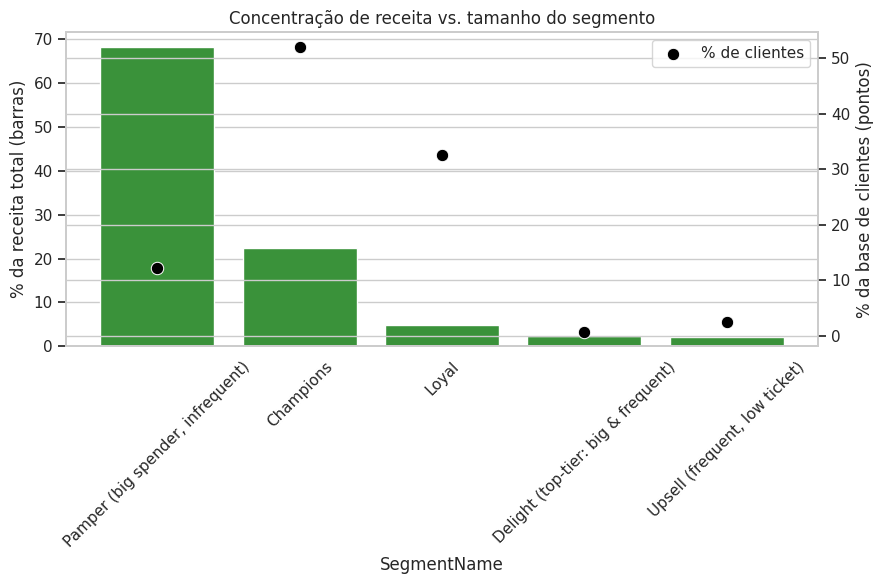

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=profile.index, y=profile["pct_of_revenue"], order=order, ax=ax, color="#2ca02c")
ax2 = ax.twinx()
sns.scatterplot(x=profile.index, y=profile["pct_of_customers"], ax=ax2, color="black", s=80, zorder=5, label="% de clientes")
ax.set_ylabel("% da receita total (barras)")
ax2.set_ylabel("% da base de clientes (pontos)")
ax.set_title("Concentração de receita vs. tamanho do segmento")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

A v1 misturava Recência (dias), Frequência (contagem) e Monetário (£/100)
como três linhas na mesma escala secundária de um gráfico de barras — três
unidades diferentes numa única escala visual é enganoso (a altura relativa
das linhas não é comparável). Aqui: painéis separados por unidade para o
perfil bruto, e um gráfico dedicado — barra de % de receita com pontos de %
de clientes sobrepostos — para a pergunta que mais importa: concentração de
receita por segmento.

## 10. Resumo executivo

In [15]:
summary_lines = []
for name, row in profile.iterrows():
    summary_lines.append(
        f"- **{name}**: {int(row['n_customers'])} clientes ({row['pct_of_customers']}% da base) "
        f"respondem por {row['pct_of_revenue']}% da receita. "
        f"Ticket médio £{row['avg_monetary']:.0f}, {row['avg_frequency']:.1f} pedidos, "
        f"última compra há {row['avg_recency']:.0f} dias em média."
    )
print("\n".join(summary_lines))

- **Pamper (big spender, infrequent)**: 116 clientes (12.2% da base) respondem por 68.2% da receita. Ticket médio £13709, 10.9 pedidos, última compra há 38 dias em média.
- **Champions**: 494 clientes (52.1% da base) respondem por 22.5% da receita. Ticket médio £1062, 11.4 pedidos, última compra há 25 dias em média.
- **Loyal**: 309 clientes (32.6% da base) respondem por 4.9% da receita. Ticket médio £371, 4.9 pedidos, última compra há 80 dias em média.
- **Delight (top-tier: big & frequent)**: 7 clientes (0.7% da base) respondem por 2.3% da receita. Ticket médio £7675, 28.9 pedidos, última compra há 12 dias em média.
- **Upsell (frequent, low ticket)**: 23 clientes (2.4% da base) respondem por 2.1% da receita. Ticket médio £2138, 27.4 pedidos, última compra há 11 dias em média.


**Principais correções em relação à v1**: consideração das duas planilhas
do Online Retail II (Recency/Frequency não truncados em um ano), k
justificado por silhouette (não hardcoded), log-transform para lidar com a
assimetria residual de Monetary/Frequency, nomeação de segmento robusta a
mudança de dados, e a métrica de % de receita por segmento que efetivamente
prioriza investimento de CRM.

**Limitação desta execução**: os números acima vêm de dados sintéticos
(ver nota no topo do notebook) — antes de usar para decisão real, rode
`rfm_pipeline.py` contra o `online_retail_II.xlsx` real, com as duas
planilhas concatenadas.